## This imports the libraries, and the data we found from american health association

In [222]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

df = pd.read_csv('denial_risk.csv')

print(f"Starting Dataset Shape is: {df.shape}")

Starting Dataset Shape is: (200000, 44)


## Classifies the data into distinct categories

In [223]:
nominal = ['payer_name', 'provider_specialty', 'request_type', 'denial_outcome']

for col in nominal:
    df[col] = df[col].fillna("Null") #Null for string columns

    groups = df[col].value_counts().nlargest(9).index
    df[col] = df[col].apply(lambda x: x if x in groups or x == "Null" else "Other")

    print(f"Unique groups in {col}: of type: {df[col].unique()} ")

Unique groups in payer_name: of type: <StringArray>
['CMS-Medicare', 'Humana', 'Kaiser', 'UnitedHealthcare', 'Anthem', 'Regional Medicaid', 'Cigna', 'BlueCross', 'Aetna', 'Null']
Length: 10, dtype: str 
Unique groups in provider_specialty: of type: <StringArray>
[          'Other',    'Primary Care',   'Endocrinology',     'Dermatology',        'Oncology',       'Neurology',    'Rheumatology',
      'Cardiology',      'Nephrology', 'Pain Management',            'Null']
Length: 11, dtype: str 
Unique groups in request_type: of type: <StringArray>
['Imaging', 'Medication', 'Infusion', 'Surgery', 'Therapy', 'DME', 'Procedure']
Length: 7, dtype: str 
Unique groups in denial_outcome: of type: <StringArray>
['Denied', 'Approved']
Length: 2, dtype: str 


## Classifies the data for numerical analysis

In [224]:
ratioCols = ['patient_age', 'policy_match_score', 'note_completeness_score', 'requested_amount_usd']

for col in ratioCols:
    if df[col].isnull().sum() > 0:
        means = df[col].mean()
        sigma = df[col].std()

        def heuresticFill(x):
            if pd.isnull(x):
                return means + (sigma * random.uniform(-2, 2))
            return x

        df[col] = df[col].apply(heuresticFill)

df[ratioCols].describe()

,patient_age,policy_match_score,note_completeness_score,requested_amount_usd
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,61.826045,1.760311,2.041801,2894.043925
std,17.115538,32.770883,38.076129,5284.746280
min,-5.000000,-63.570579,-73.727647,33.000000
25%,50.000000,0.570000,0.495000,723.660000
50%,62.000000,0.693000,0.613000,1364.830000
75%,74.000000,0.806000,0.726000,3005.945000
max,120.000000,999.000000,999.000000,334985.966845


In [225]:
for col in ratioCols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound)

print("Outliers have been trimmed, to have normal data")

Outliers have been trimmed, to have normal data


## Making figures for analysis

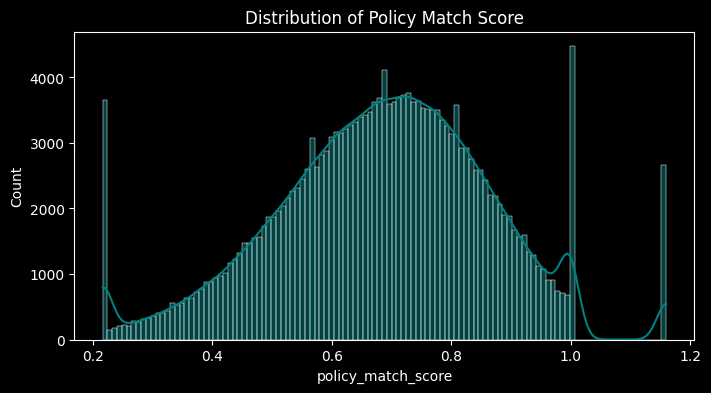

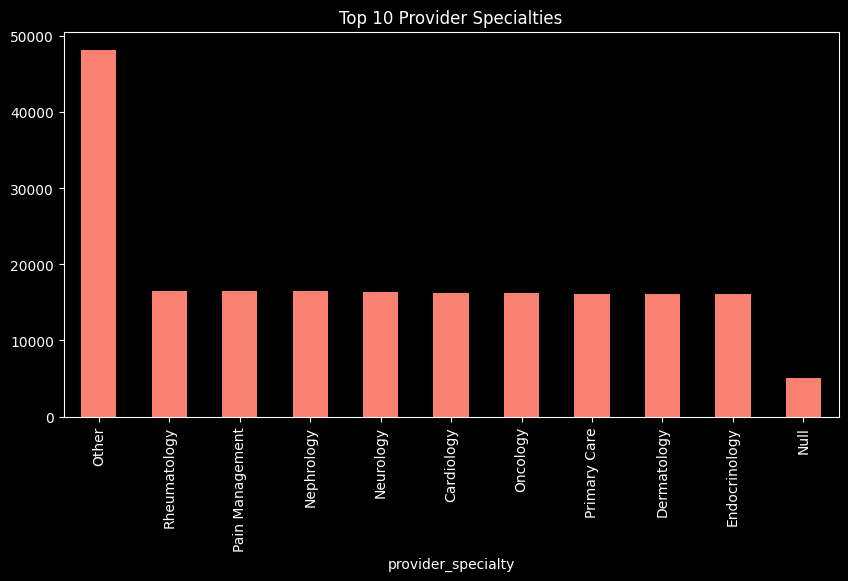

In [226]:
plt.figure(figsize=(8, 4))
sns.histplot(df['policy_match_score'], kde=True, color='teal')
plt.title('Distribution of Policy Match Score')
plt.show()

plt.figure(figsize=(10, 5))
df['provider_specialty'].value_counts().plot(kind='bar', color='salmon')
plt.title('Top 10 Provider Specialties')
plt.show()

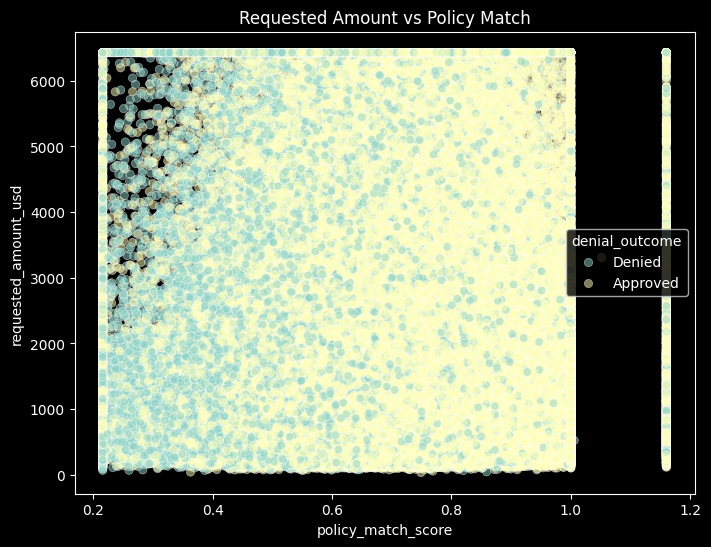

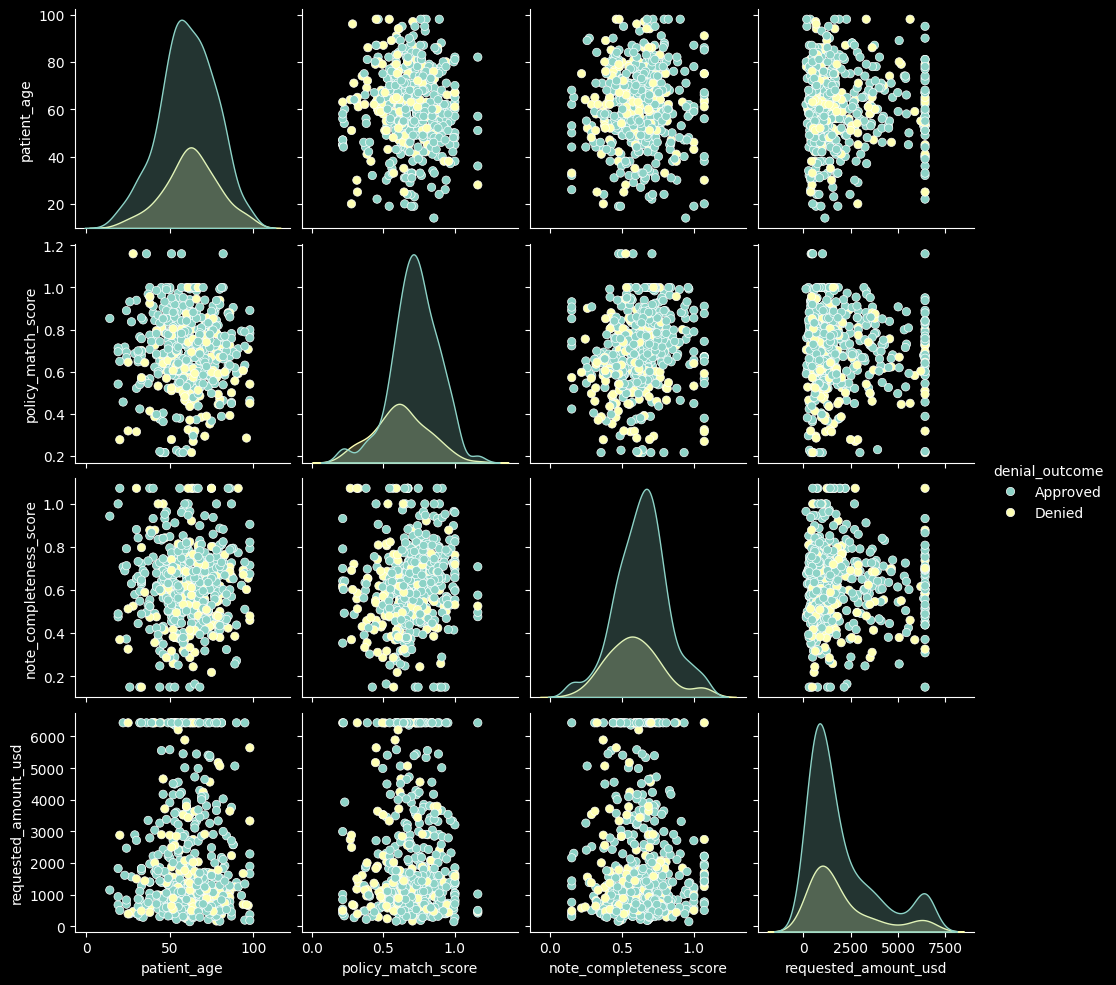

In [227]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='policy_match_score', y='requested_amount_usd', hue='denial_outcome', alpha=0.5)
plt.title('Requested Amount vs Policy Match')
plt.show()

sns.pairplot(df[ratioCols + ['denial_outcome']].sample(500), hue='denial_outcome')
plt.show()

## Training the Data

In [228]:
from sklearn.model_selection import train_test_split

y = df['denial_outcome'].map({'Denied': 1, 'Approved': 0})

X = df[ratioCols]

X_train, X_test, y_train, testing = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} records")
print(f"Testing set size: {X_test.shape[0]} records")

Training set size: 160000 records
Testing set size: 40000 records


In [229]:
from sklearn.linear_model import LogisticRegression

insurance_model = LogisticRegression(max_iter=10000)
insurance_model.fit(X_train, y_train)

print("The model has been trained!")

The model has been trained!


Model Accuracy is: 75.52%

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.96      0.85     29656
           1       0.60      0.16      0.25     10344

    accuracy                           0.76     40000
   macro avg       0.68      0.56      0.55     40000
weighted avg       0.72      0.76      0.70     40000



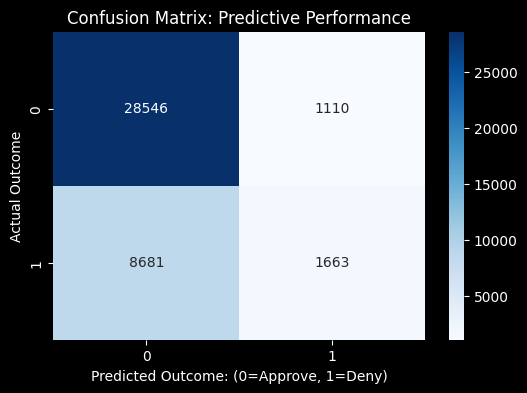

In [230]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

predictions = insurance_model.predict(X_test)

accuracy = accuracy_score(testing, predictions)

print(f"Model Accuracy is: {accuracy * 100:.2f}%")
print()
print("Classification Report:")
print(classification_report(testing, predictions))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(testing, predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Outcome: (0=Approve, 1=Deny)')
plt.ylabel('Actual Outcome')
plt.title('Confusion Matrix: Predictive Performance')
plt.show()

In [231]:

probabilities = insurance_model.predict_proba(X_test)[:, 1]

def thresholdFinder(y_true, y_probs):
    bestThreshold = 0.4
    bestAccuracy = 0

    for threshold in np.arange(0.01, 0.99, 0.01):
        current = (y_probs >= threshold).astype(int)
        accuracy = accuracy_score(y_true, current)

        if accuracy > bestAccuracy:
            bestAccuracy = accuracy
            bestThreshold = threshold

    return bestThreshold, bestAccuracy

thresholdBest, newAccuracy = thresholdFinder(testing, probabilities)

print(f"Optimal Threshold is: {thresholdBest:.2f}")
print(f"New Accuracy is: {newAccuracy * 100:.2f}%")

Optimal Threshold is: 0.46
New Accuracy is: 75.71%


In [232]:
finalPredictions = (probabilities >= thresholdBest).astype(int)
initialAccuracy = accuracy_score(testing, predictions)
print(f"Original Accuracy: {initialAccuracy * 100:.2f}%")
print(f"Final Optimized Accuracy: {newAccuracy * 100:.2f}%")
print(f"Accuracy Improvement: {(newAccuracy - initialAccuracy) * 100:.2f}%")

print()
print("Final Performance Report:")
print(classification_report(testing, finalPredictions))

Original Accuracy: 75.52%
Final Optimized Accuracy: 75.71%
Accuracy Improvement: 0.19%

Final Performance Report:
              precision    recall  f1-score   support

           0       0.78      0.95      0.85     29656
           1       0.58      0.22      0.32     10344

    accuracy                           0.76     40000
   macro avg       0.68      0.58      0.58     40000
weighted avg       0.73      0.76      0.71     40000

